In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load all hives from unified CSV and filter by box_id
_all = pd.read_csv('../../data/12062026all_boxes.csv')
_all.rename(columns={'Hive name': 'box_id'}, inplace=True)
df2  = _all[_all['box_id'] == 'Box2'].copy()
df4  = _all[_all['box_id'] == 'Box4'].copy()
df13 = _all[_all['box_id'] == 'Box13'].copy()
df2.columns

Index(['Hive name', 'Time', 'Temperature heart', 'Humidity heart', 'Frequency',
       'Volume', 'Temperature scale', 'Humidity scale', 'Weight'],
      dtype='object')

In [4]:
dfs = [df2, df4, df13]

#Convert the 'Time' column to datetime and sort the dataframes by time
for i, df in enumerate(dfs):
    dfs[i]['Time'] = pd.to_datetime(df['Time'])
    dfs[i] = df.sort_values('Time').reset_index(drop=True)

# Extract year from 'Time' for easier filtering
for i, df in enumerate(dfs):
    dfs[i]['year'] = dfs[i]['Time'].dt.year

C:\Users\migue\AppData\Local\Temp\ipykernel_7780\3155470810.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs[i]['Time'] = pd.to_datetime(df['Time'])
C:\Users\migue\AppData\Local\Temp\ipykernel_7780\3155470810.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs[i]['Time'] = pd.to_datetime(df['Time'])
C:\Users\migue\AppData\Local\Temp\ipykernel_7780\3155470810.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs[i]['Time'] = pd.to_datetime(df['Time'])


In [5]:
# Check for missing values in each DataFrame
for i, df in enumerate(dfs):
    nulls = dfs[i].isnull().sum()
    pct = (nulls / len(dfs[i]) * 100).round(2)
    #print(pd.DataFrame({'nulos': nulls, '% nulo': pct}))

In [9]:
# Create dictionaries to access data by year
box2_years = {y: d for y, d in dfs[0].groupby('year')}
box4_years = {y: d for y, d in dfs[1].groupby('year')}
box13_years = {y: d for y, d in dfs[2].groupby('year')}

# Access data for specific years
box2_2024 = box2_years[2024]
box2_2025 = box2_years[2025]
box2_2026 = box2_years[2026]

box4_2024 = box4_years[2024]
box4_2025 = box4_years[2025]
box4_2026 = box4_years[2026]

box13_2024 = box13_years[2024]
box13_2025 = box13_years[2025]
box13_2026 = box13_years[2026]

In [11]:
def clean_weight(df, max_step=3):

    df = df.copy()
    df = df.sort_values('Time')

    diff = df['Weight'].diff().abs()

    df.loc[diff > max_step, 'Weight'] = None

    df['Weight'] = df['Weight'].interpolate()

    return df

def extract_heart(df):

    return df[df['Temperature heart'].notna()][[
        'Time',
        'Temperature heart',
        'Humidity heart',
        'Frequency',
        'Volume',
        'Weight'
    ]].reset_index(drop=True)

import matplotlib.pyplot as plt

def plot_basic(df, title):

    fig, axes = plt.subplots(4, 1, figsize=(14,8), sharex=True)

    axes[0].plot(df['Time'], df['Temperature heart'])
    axes[0].set_ylabel("Temp")

    axes[1].plot(df['Time'], df['Humidity heart'])
    axes[1].set_ylabel("Humidity")

    axes[2].plot(df['Time'], df['Weight'])
    axes[2].set_ylabel("Weight")

    axes[3].plot(df['Time'], df['Frequency'])
    axes[3].set_ylabel("Activity")

    plt.suptitle(title)
    plt.show()

In [22]:
def create_features(df):

    df = df.copy()
    df = df.sort_values("Time")

    window = 18  # ~3h

    # 🔥 VARIABILITY (clave)
    df["temp_std"] = df["Temperature heart"].rolling(window).std()
    df["humidity_std"] = df["Humidity heart"].rolling(window).std()
    df["activity_std"] = df["Frequency"].rolling(window).std()

    # 🔁 CHANGES
    df["temp_diff"] = df["Temperature heart"].diff()
    df["activity_diff"] = df["Frequency"].diff()
    df["weight_diff"] = df["Weight"].diff()

    # ⚡ INSTABILITY
    df["temp_std_diff"] = df["temp_std"].diff()
    df["activity_std_diff"] = df["activity_std"].diff()

    # 🔴 RANGE
    df["temp_range"] = (
        df["Temperature heart"].rolling(window).max() -
        df["Temperature heart"].rolling(window).min()
    )

    # ⚖️ WEIGHT NOISE
    df["weight_std"] = df["Weight"].rolling(window).std()

    # 🧠 GLOBAL INDEX
    df["instability"] = (
        df["temp_std"].diff().abs() +
        df["activity_std"].diff().abs() +
        df["weight_std"].diff().abs()
    )

    return df.dropna()

def plot_instability(df, title):

    plt.figure(figsize=(14,5))

    plt.plot(df['Time'], df['instability'])

    plt.title(f"Instability index - {title}")
    plt.ylabel("Instability")
    plt.xlabel("Time")

    plt.show()

def plot_variability(df, title):

    plt.figure(figsize=(14,5))

    plt.plot(df['Time'], df['temp_std'], label='Temp std')
    plt.plot(df['Time'], df['activity_std'], label='Activity std')

    plt.legend()
    plt.title(f"Variability - {title}")

    plt.show()


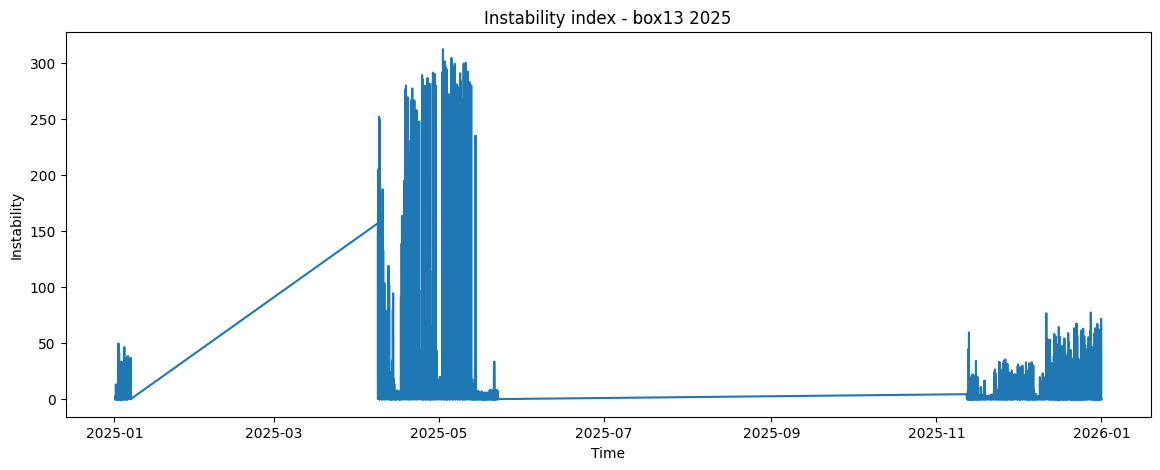

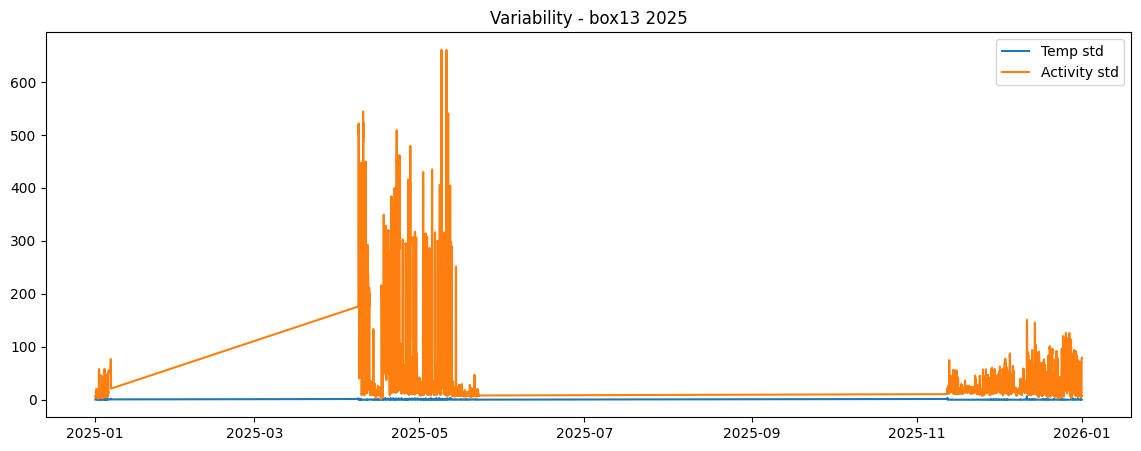

In [23]:
df = box13_2025.copy()
df = clean_weight(df)
df = extract_heart(df)
df = create_features(df)
plot_instability(df, "box13 2025")
plot_variability(df, "box13 2025")

In [32]:
swarm_events = {
    13: ["2025-04-16"],
    4: ["2025-04-23"],
    2: ["2024-05-24 13:26:57"]
}
def plot_with_events(df, swarm_times, title):

    plt.figure(figsize=(14,5))

    plt.plot(df['Time'], df['instability'], label='Instability')

    for t in swarm_times:
        plt.axvline(pd.to_datetime(t), color='red')

    plt.legend()
    plt.title(title)

    plt.show()

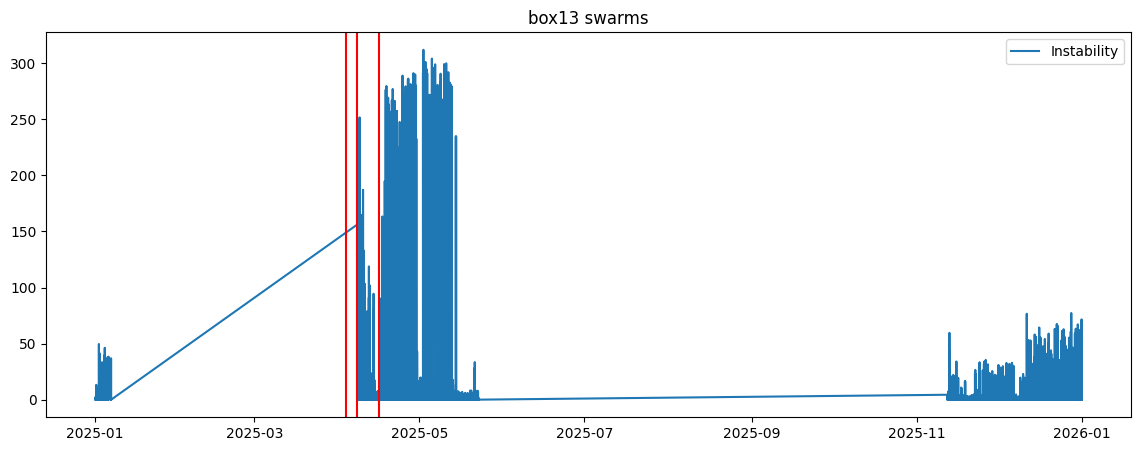

In [25]:
plot_with_events(df, swarm_events[13], "box13 swarms")

In [28]:
def plot_zoom_swarm(df, swarm_time, hours_before=72, hours_after=12):

    swarm_time = pd.to_datetime(swarm_time)

    start = swarm_time - pd.Timedelta(hours=hours_before)
    end   = swarm_time + pd.Timedelta(hours=hours_after)

    df_zoom = df[(df['Time'] >= start) & (df['Time'] <= end)]

    plt.figure(figsize=(14,5))

    plt.plot(df_zoom['Time'], df_zoom['instability'], label='Instability')

    plt.axvline(swarm_time, color='red', label='Swarm')

    plt.legend()
    plt.title(f"Zoom around swarm: {swarm_time}")

    plt.show()

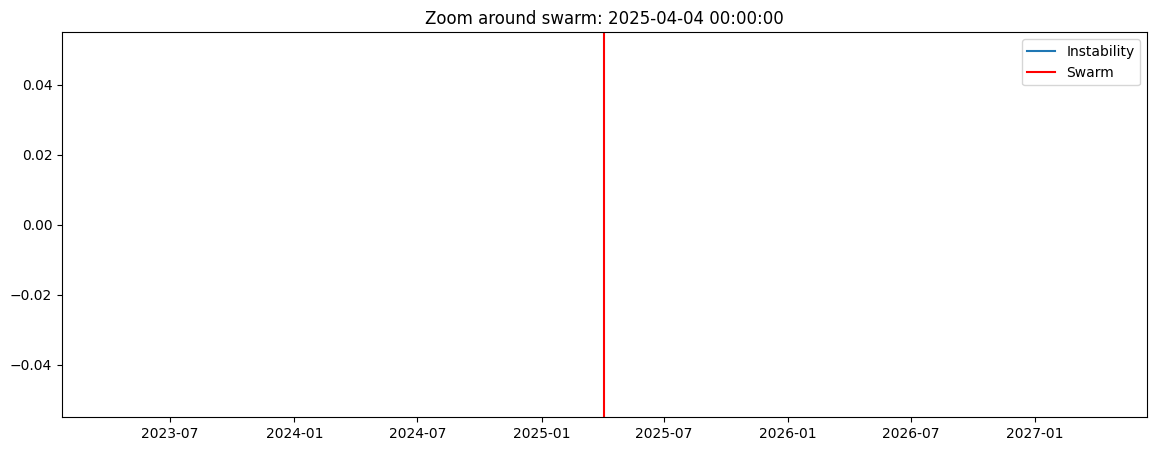

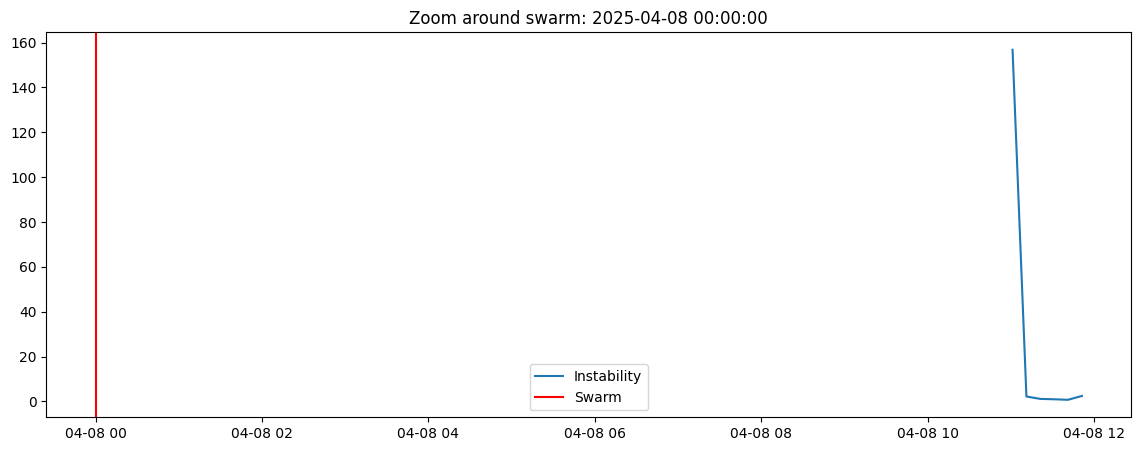

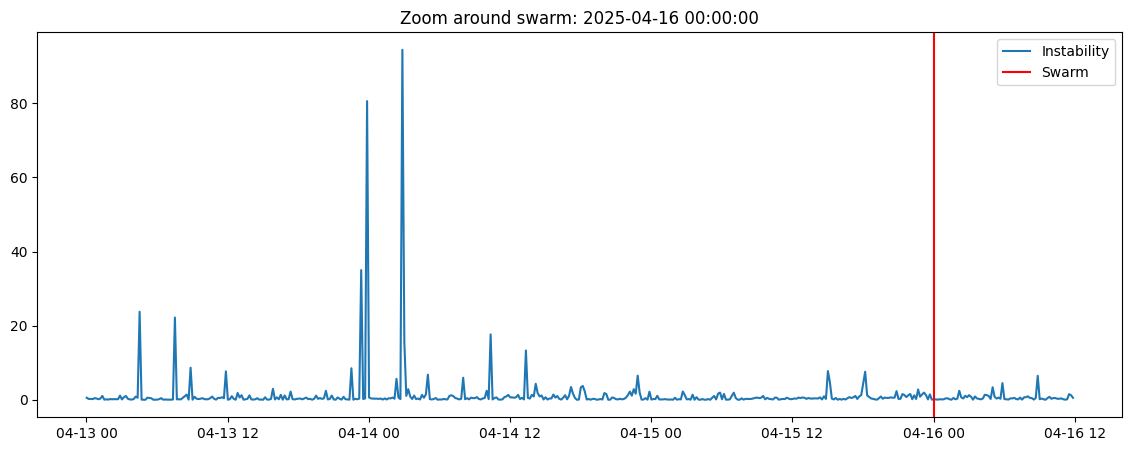

In [29]:
for t in swarm_events[13]:
    plot_zoom_swarm(df, t)

In [ ]:
def swarm_prepost_stats(df, swarm_time, before_h=72, after_h=12):
    t = pd.to_datetime(swarm_time)
    pre = df[(df['Time'] >= t - pd.Timedelta(hours=before_h)) & (df['Time'] < t)]
    post = df[(df['Time'] > t) & (df['Time'] <= t + pd.Timedelta(hours=after_h))]
    def keep(s):
        return {
            'n': len(s),
            'inst_mean': s['instability'].mean(),
            'inst_std': s['instability'].std(),
            'temp_std_mean': s['temp_std'].mean(),
            'activity_std_mean': s['activity_std'].mean()
        }
    b, a = keep(pre), keep(post)
    return {
        'swarm_time': t,
        'before': b, 'after': a,
        'd_inst_mean': a['inst_mean'] - b['inst_mean']
    }

def plot_pre_swarm(df, swarm_time, before_h=72):
    t = pd.to_datetime(swarm_time)
    sel = df[(df['Time'] >= t - pd.Timedelta(hours=before_h)) & (df['Time'] <= t)]
    plt.figure(figsize=(14, 4))
    plt.plot(sel['Time'], sel['instability'], label='Instability')
    plt.axvline(t, color='red', linestyle='--', label='Swarm')
    m = sel['instability'].mean()
    plt.axhline(m, color='gray', linestyle=':', label=f'Pre mean {m:.2f}')
    plt.title(f"Pre-swarm {before_h}h around {t}")
    plt.legend()
    plt.show()

{'swarm_time': Timestamp('2025-04-16 00:00:00'), 'before': {'n': 576, 'inst_mean': 2.820592594709193, 'inst_std': 11.342664222500161, 'temp_std_mean': 0.49044287824984306, 'activity_std_mean': 43.05380093627574}, 'after': {'n': 144, 'inst_mean': 1.4737788854824774, 'inst_std': 8.081331585036976, 'temp_std_mean': 0.1584192731817421, 'activity_std_mean': 14.13499642479453}, 'd_inst_mean': -1.3468137092267156}


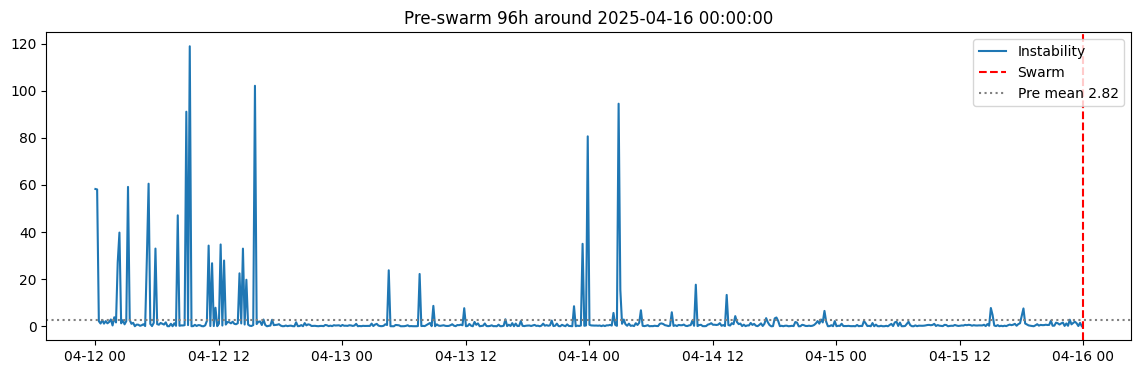

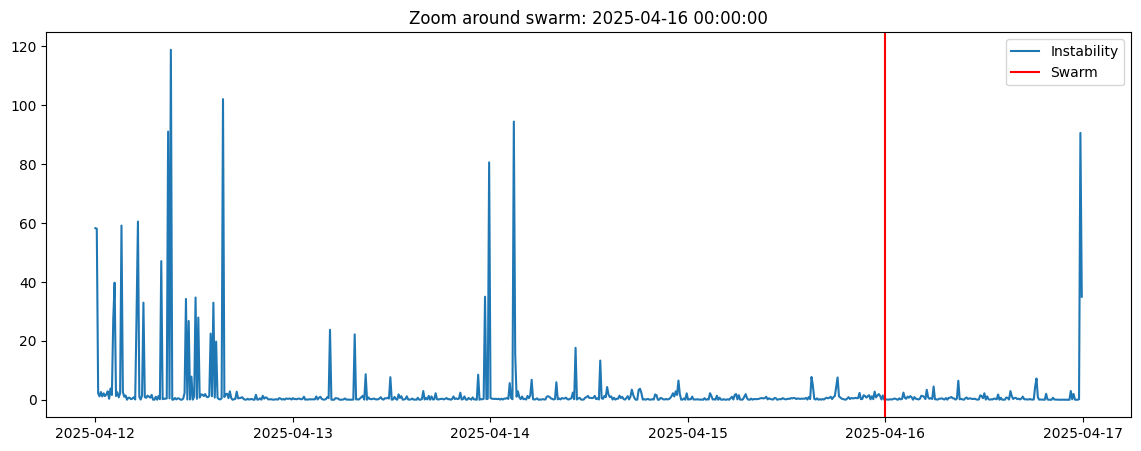

In [34]:
for t in swarm_events[13]:
    print(swarm_prepost_stats(df, t, before_h=96, after_h=24))
    plot_pre_swarm(df, t, before_h=96)
    plot_zoom_swarm(df, t, hours_before=96, hours_after=24)

cand: 2025-04-16 08:51:07 delta inst mean -0.2815101409587911


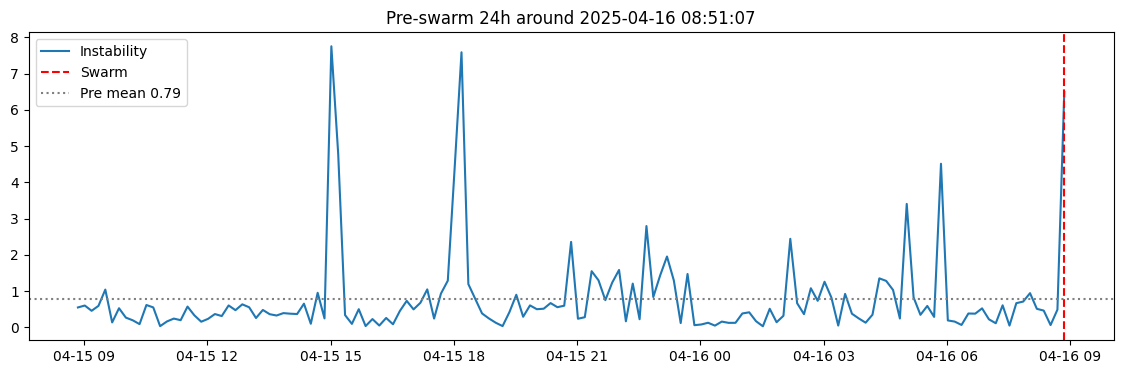

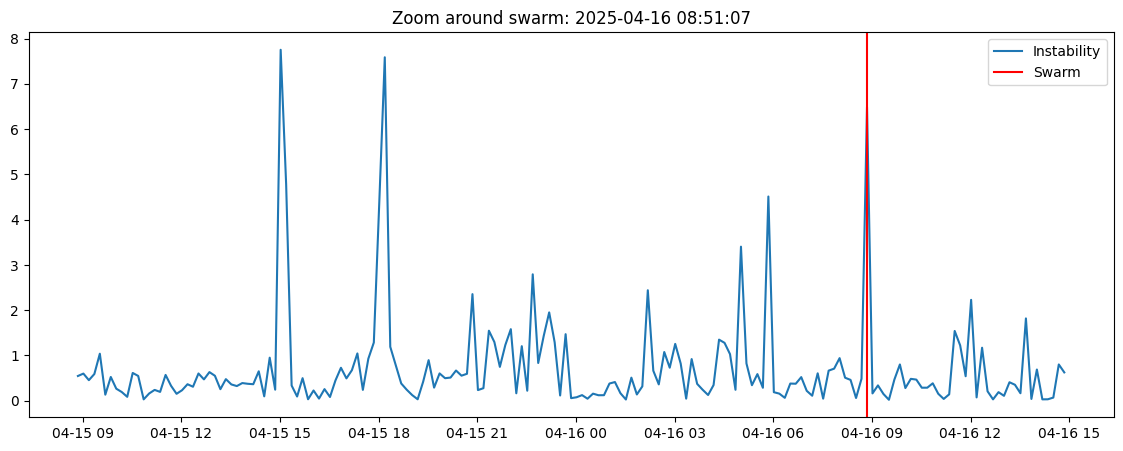

cand: 2025-04-16 12:01:07 delta inst mean -0.35132356598003134


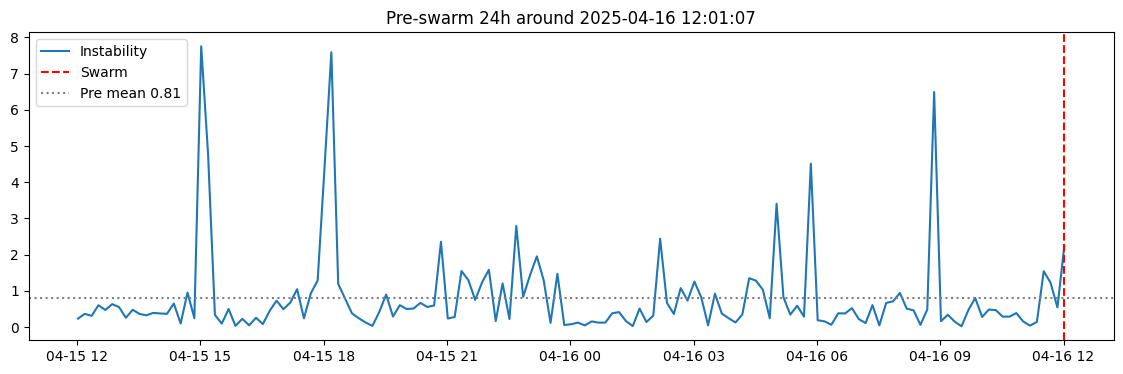

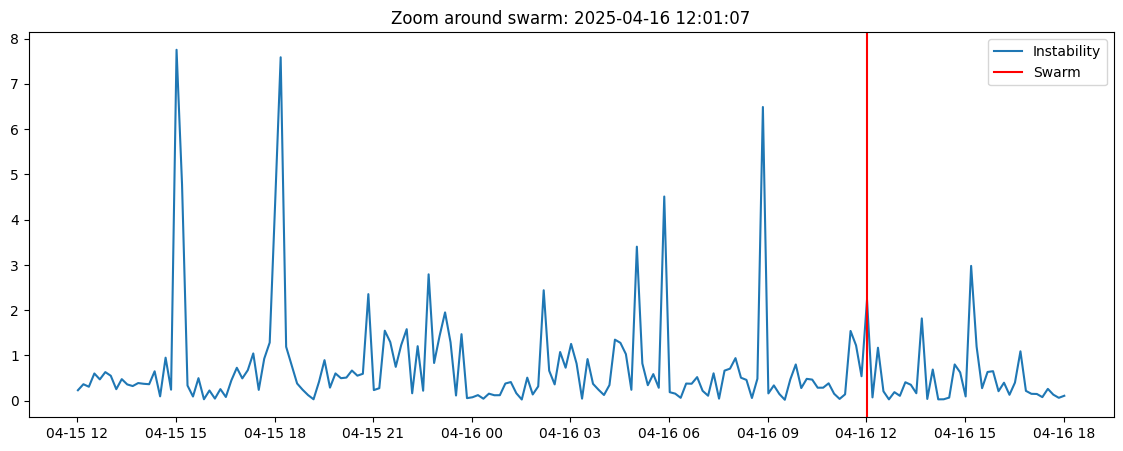

cand: 2025-04-16 13:41:07 delta inst mean -0.06675140848521488


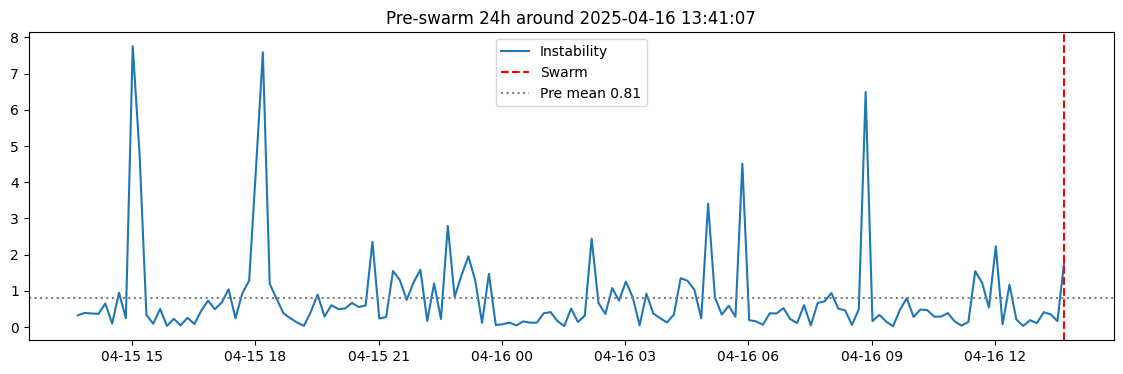

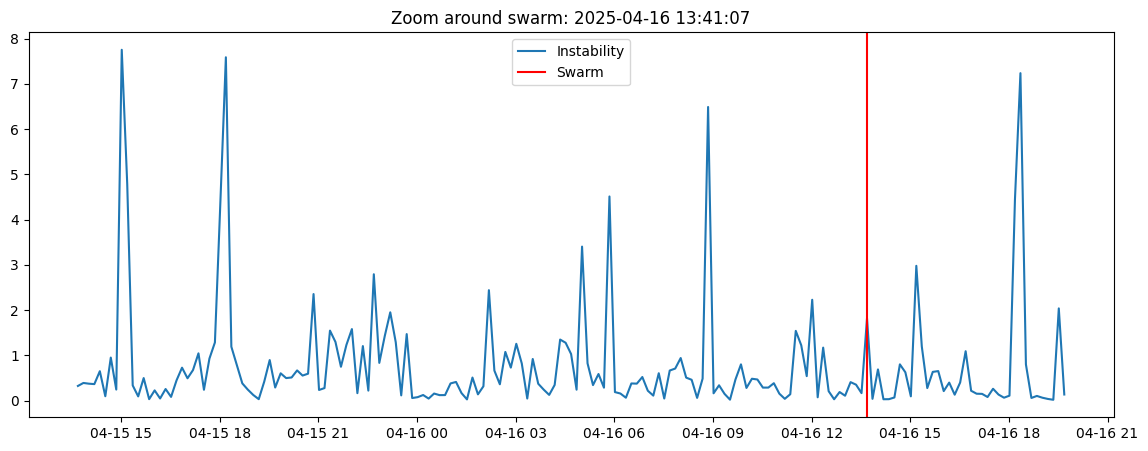

cand: 2025-04-16 11:31:07 delta inst mean -0.23332921560292885


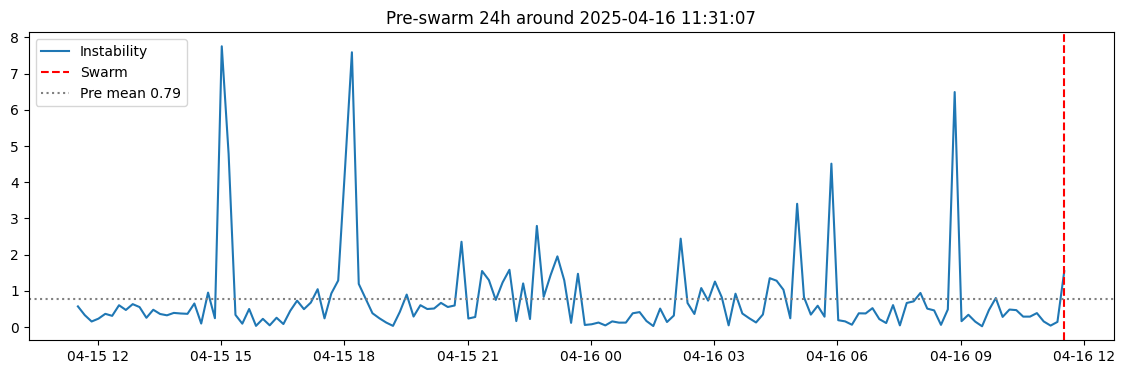

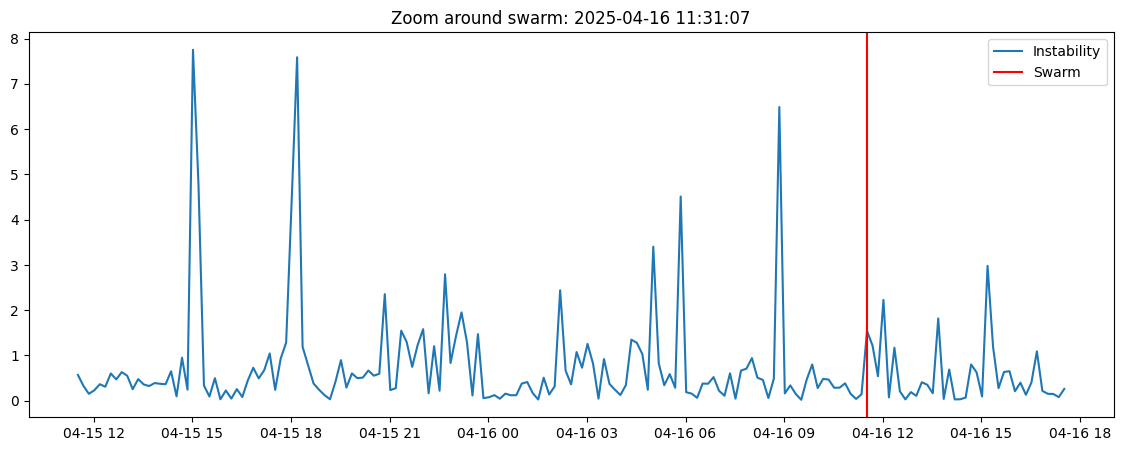

cand: 2025-04-16 11:41:07 delta inst mean -0.27031820646925087


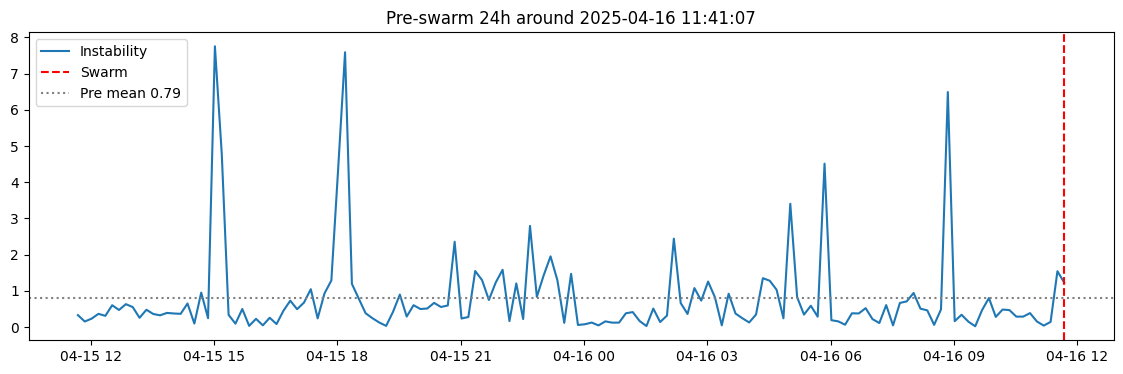

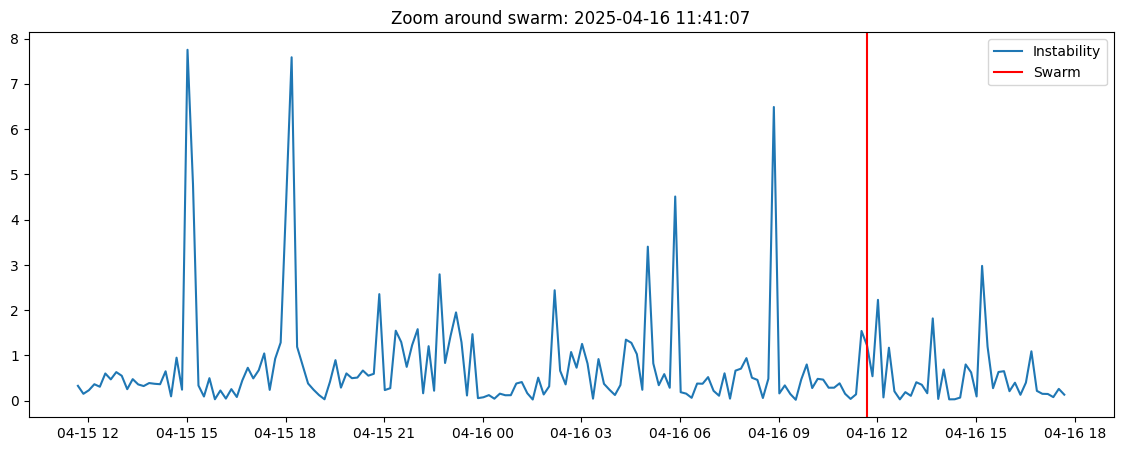

cand: 2025-04-16 12:21:07 delta inst mean -0.07316902036374662


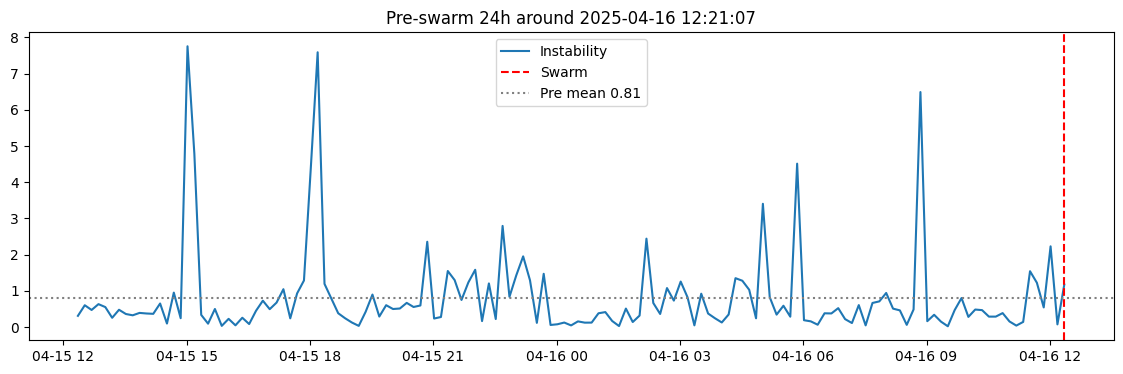

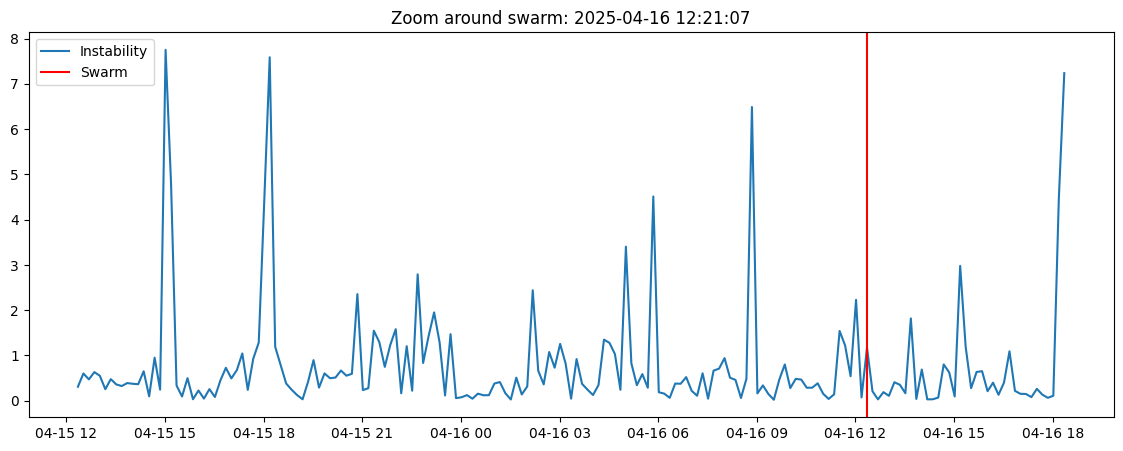

cand: 2025-04-16 08:01:07 delta inst mean -0.0949151368384058


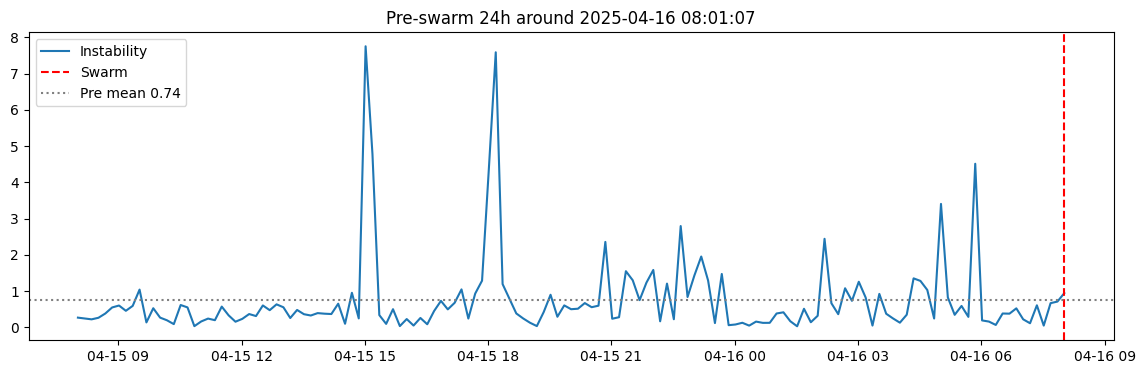

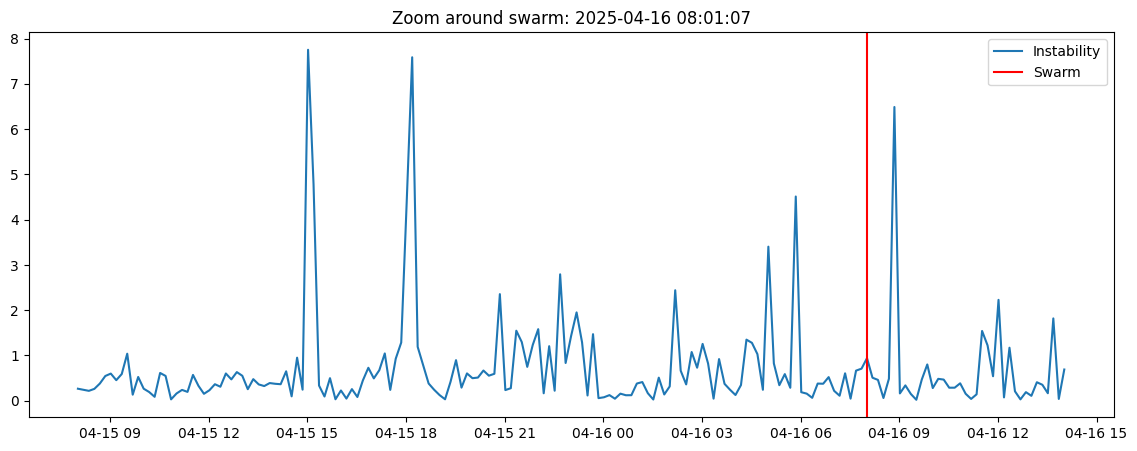

cand: 2025-04-16 09:51:07 delta inst mean -0.20296321583145893


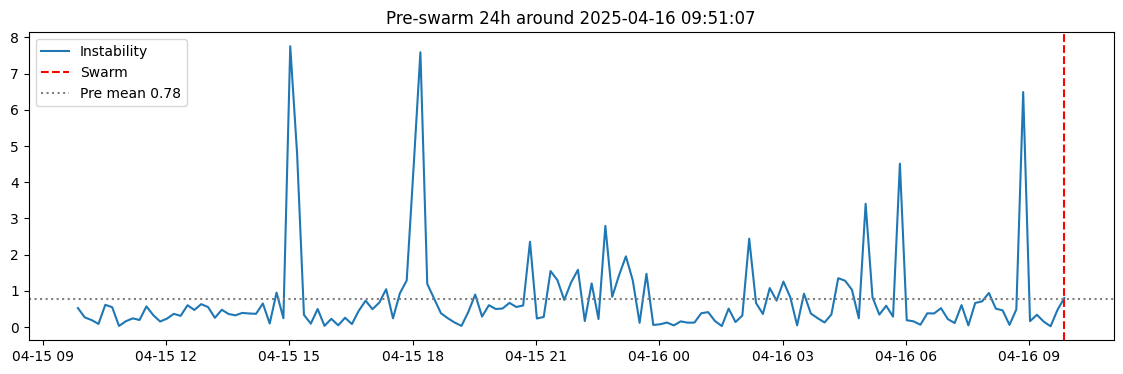

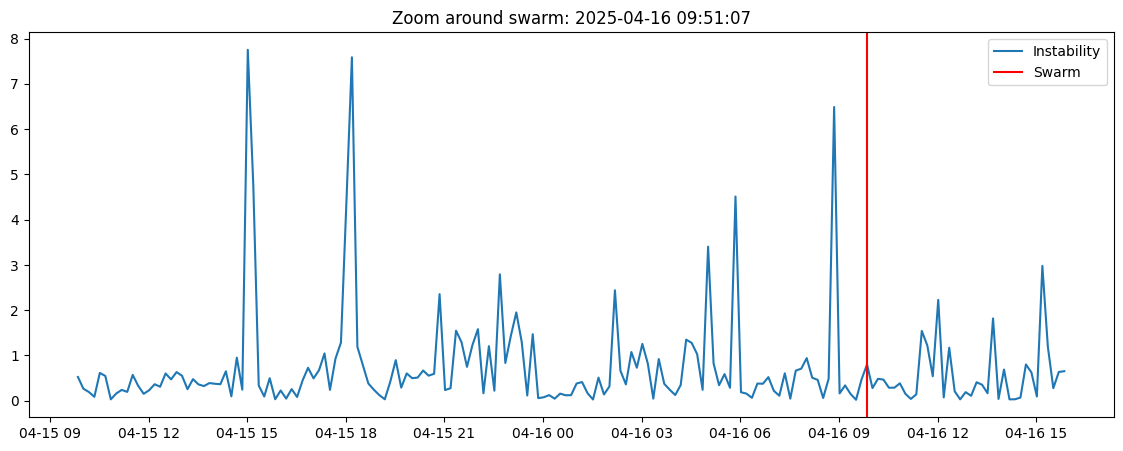

: 

In [ ]:
def candidate_swarm_times(df, day, t0='08:00', t1='16:00', topk=5):
    day = pd.to_datetime(day).date()
    start = pd.Timestamp(f"{day} {t0}")
    end   = pd.Timestamp(f"{day} {t1}")
    sel = df[(df['Time'] >= start) & (df['Time'] <= end)]
    if sel.empty:
        return []
    top = sel.nlargest(topk, 'instability')
    return top['Time'].tolist()

def evaluate_candidate(df, t):
    stats = swarm_prepost_stats(df, t, before_h=24, after_h=6)
    print("cand:", t, "delta inst mean", stats['d_inst_mean'])
    plot_pre_swarm(df, t, before_h=24)
    plot_zoom_swarm(df, t, hours_before=24, hours_after=6)
    return stats

dia = "2025-04-16"
cands = candidate_swarm_times(df, dia, t0='06:00', t1='14:00', topk=8)
for t in cands:
    evaluate_candidate(df, t)